In [1]:
!pip install scipy==1.11.4

In [2]:
!git clone https://github.com/jonschwenk/RivGraph.git

fatal: destination path 'RivGraph' already exists and is not an empty directory.


In [3]:
import os
os.chdir('/content/RivGraph')
os.listdir()

['.github',
 '.gitignore',
 '.git',
 'https:',
 'examples',
 'tests',
 'rivgraph',
 'docs',
 'pyproject.toml',
 'CHANGELOG.md',
 'README.md',
 '.gitattributes',
 'environment.yml',
 'LICENSE.txt',
 'paper',
 'RivGraph',
 '.codex']

In [4]:
!pip install shapely --only-binary :all:
!pip install fastdtw loguru numpy scipy matplotlib scikit-image networkx opencv-python

In [5]:
import scipy
print(scipy.__version__)

1.11.4


In [6]:
import sys
sys.path.insert(0, '/content/RivGraph')

import rivgraph.classes as classes

print("Available classes in rivgraph.classes:")
print([name for name in dir(classes) if not name.startswith('_')])

Available classes in rivgraph.classes:
['CRS', 'LineString', 'centerline', 'cu', 'dd', 'delta', 'distance_transform_edt', 'dm', 'du', 'get_extension_for_format', 'gpd', 'gu', 'io', 'lnu', 'logger', 'm2g', 'mu', 'np', 'nx', 'os', 'plt', 'rasters', 'rd', 'river', 'rivnetwork', 'ru', 'signal', 'sys']


In [7]:
import sys
sys.path.insert(0, '/content/RivGraph')

import rivgraph
print(dir(rivgraph))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'classes', 'deltas', 'directionality', 'export_schema', 'geo_utils', 'im_utils', 'io_utils', 'ln_utils', 'mask_to_graph', 'mask_utils', 'ordered_set', 'rasters', 'rivers', 'walk']


In [8]:
!pip install gdown

import gdown
# Extract file
file_id = '1a6C2pF1Rp4MXMMfjFecyDMbcB9yF0jsf'
url = f'https://drive.google.com/uc?id={file_id}'

In [9]:
import sys
sys.path.insert(0, '/content/RivGraph')

from shapely.ops import unary_union
import rivgraph.mask_utils
rivgraph.mask_utils.cascaded_union = unary_union

from rivgraph.classes import rivnetwork
import gdown
import os

# Use the EXACT path from the list above
# The URL is for downloading, so we need to download it first
output_path = '/content/mask.tif'
gdown.download(url, output_path, quiet=False)

rn = rivnetwork(
    name='delta',
    path_to_mask=output_path
)

print("✓ Image loaded successfully!")

Downloading...
From (original): https://drive.google.com/uc?id=1a6C2pF1Rp4MXMMfjFecyDMbcB9yF0jsf
From (redirected): https://drive.google.com/uc?id=1a6C2pF1Rp4MXMMfjFecyDMbcB9yF0jsf&confirm=t&uuid=068a3441-ceb1-4619-a806-389fb0056c4b
To: /content/mask.tif
100%|██████████| 207M/207M [00:00<00:00, 329MB/s]


✓ Image loaded successfully!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
---------- New Run ----------


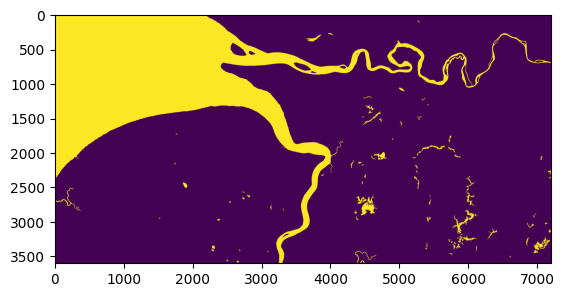

In [10]:
from rivgraph.classes import delta
import matplotlib.pyplot as plt

# Define the path to the georeferenced binary image.
mask_path = output_path
# Results will be saved with this name
name = 'papua'

from google.colab import drive
drive.mount('/content/drive')

# Where do you want to store the results? This folder will be created if it doesn't exist.
results_folder = '/content/drive/My Drive/es2/'

# Boot up the delta class! We set verbose=True to see progress of processing.
papua = delta(name, mask_path, results_folder=results_folder, verbose=True)

# The mask has been re-binarized and stored as an attribute of colville:
plt.imshow(papua.Imask)

`np.NaN` not found in rivgraph/im_utils.py or already patched. Skipping patch.


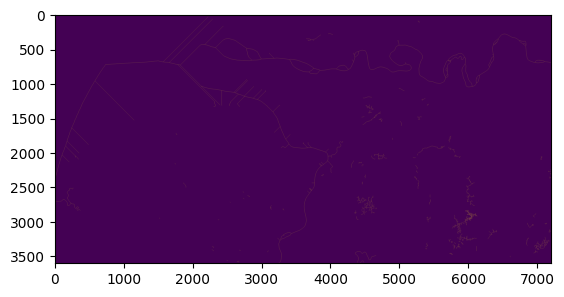

In [11]:
import os
import sys
import importlib
import numpy as np # Ensure numpy is available for version check

# Define the path to the problematic file within the RivGraph installation
rivgraph_base_path = '/content/RivGraph' # Assuming RivGraph is cloned here
im_utils_file_path = os.path.join(rivgraph_base_path, 'rivgraph', 'im_utils.py')

# --- Start Patching Logic ---
try:
    with open(im_utils_file_path, 'r') as f:
        content = f.read()

    # Check if the problematic `np.NaN` exists in the file content
    if "vals[:] = np.NaN" in content:
        # Check if the current numpy version is 2.0 or higher
        if np.__version__.startswith('2.'):
            print("Found NumPy 2.0+ incompatible code in rivgraph/im_utils.py. Applying patch...")
            # Replace np.NaN with np.nan
            patched_content = content.replace("vals[:] = np.NaN", "vals[:] = np.nan")

            # Write back the patched content
            with open(im_utils_file_path, 'w') as f:
                f.write(patched_content)
            print("rivgraph/im_utils.py patched successfully.")

            # Attempt to reload modules that might have loaded the old code
            # Reload in dependency order: im_utils -> mask_to_graph -> classes
            if 'rivgraph.im_utils' in sys.modules:
                importlib.reload(sys.modules['rivgraph.im_utils'])
            if 'rivgraph.mask_to_graph' in sys.modules:
                importlib.reload(sys.modules['rivgraph.mask_to_graph'])
            # Re-import RivGraph classes, as the delta object's methods might refer to old module states
            from rivgraph.classes import delta
            from rivgraph.classes import rivnetwork # Also reload rivnetwork if used elsewhere

            print("Relevant RivGraph modules reloaded. Re-instantiating delta object...")
            # Re-instantiate the papua object to ensure it uses the newly loaded functions
            # Use the correct mask_path and results_folder variables already defined
            papua = delta(name=name, mask_path=mask_path, results_folder=results_folder, verbose=True)
            print("Delta object re-instantiated.")
        else:
            print("NumPy version is < 2.0.0, no patch needed for np.NaN. Skipping patch.")
    else:
        print("`np.NaN` not found in rivgraph/im_utils.py or already patched. Skipping patch.")

except FileNotFoundError:
    print(f"Error: rivgraph/im_utils.py not found at {im_utils_file_path}. Cannot apply patch.")
except Exception as e:
    print(f"An error occurred during patching: {e}")
    # If patching fails, re-raise the original error or provide instructions
    print("Patching failed. Please consider manually downgrading NumPy to < 2.0.0, then restart the runtime.")
    print("Example: !pip uninstall numpy -y && !pip install numpy==1.26.4")

# --- End Patching Logic ---

# Now attempt to run the original code
papua.skeletonize()

# After running, colville has a new attribute: Iskel. Let's take a look.
plt.imshow(papua.Iskel)

In [12]:
# We use the write_geotiff() method with the "skeleton" option.
papua.to_geotiff('skeleton')

Geotiff written to /content/drive/My Drive/es2/papua_skel.tif.


In [13]:
# Simply use the compute_network() method.
papua.compute_network()

Resolving links and nodes...
links and nodes have been resolved.


In [14]:
# Now we can see that the "links" and "nodes" dictionaries have been added as colville attributes:
links = papua.links
nodes = papua.nodes
print('links: {}'.format(links.keys()))
print('nodes: {}'.format(nodes.keys()))

links: dict_keys(['idx', 'conn', 'id', 'n_networks', '_ids_finalized', '_ids_finalization_method'])
nodes: dict_keys(['idx', 'conn', 'id', '_ids_finalized', '_ids_finalization_method'])


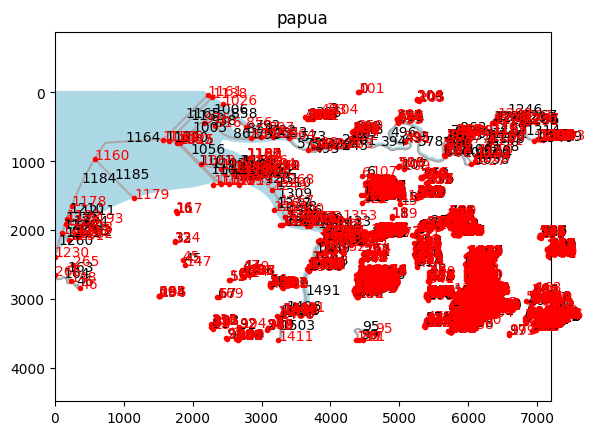

In [15]:
papua.plot('network')

In [16]:
papua.to_geovectors('network', ftype='json') # ftype can be either 'shp' or 'json'

# Let's see where the network geovector files were written:
print(papua.paths['links'])
print(papua.paths['nodes'])

/content/RivGraph/rivgraph/classes.py:516: UserWarning: Exporting a network with provisional IDs. Call finalize_ids() after topology-changing operations and before exporting if you need deterministic, final IDs.
  io.links_to_geofile(self.links, self.imshape, self.gt, self.crs, self.paths['links'], nodes=getattr(self, 'nodes', None), reproject=reproject)


/content/drive/My Drive/es2/papua_links.json
/content/drive/My Drive/es2/papua_nodes.json


/content/RivGraph/rivgraph/classes.py:522: UserWarning: Exporting a network with provisional IDs. Call finalize_ids() after topology-changing operations and before exporting if you need deterministic, final IDs.
  io.nodes_to_geofile(self.nodes, self.imshape, self.gt, self.crs, self.paths['nodes'], reproject=reproject)


In [17]:
import os

# List all files in the directory where shapefiles are expected
shapefile_dir = '/content/drive/My Drive/es2/'
print(f"Files in {shapefile_dir}:")
for root, dirs, files in os.walk(shapefile_dir):
    for file in files:
        print(os.path.join(root, file))

Files in /content/drive/My Drive/es2/:
/content/drive/My Drive/es2/Papua.tif
/content/drive/My Drive/es2/shorelinepapua.qmd
/content/drive/My Drive/es2/shorelinepapua.cpg
/content/drive/My Drive/es2/shorelinepapua.prj
/content/drive/My Drive/es2/shorelinepapua.shx
/content/drive/My Drive/es2/shorelinepapua.dbf
/content/drive/My Drive/es2/shorelinepapua.shp
/content/drive/My Drive/es2/inletpapua.dbf
/content/drive/My Drive/es2/inletpapua.qmd
/content/drive/My Drive/es2/inletpapua.prj
/content/drive/My Drive/es2/inletpapua.shx
/content/drive/My Drive/es2/inletpapua.cpg
/content/drive/My Drive/es2/inletpapua.shp
/content/drive/My Drive/es2/titik.shp
/content/drive/My Drive/es2/soree.shx
/content/drive/My Drive/es2/soree.shp
/content/drive/My Drive/es2/soree.prj
/content/drive/My Drive/es2/soree.cpg
/content/drive/My Drive/es2/soree.dbf
/content/drive/My Drive/es2/soree.qmd
/content/drive/My Drive/es2/tit.prj
/content/drive/My Drive/es2/tit.shx
/content/drive/My Drive/es2/tit.cpg
/content/

In [18]:
import geopandas as gpd

# Check shoreline
shoreline = gpd.read_file('/content/drive/My Drive/es2/garis.shp')
print("\nShoreline:")
print(shoreline)
print("Geometry types:", shoreline.geometry.type.unique())


Shoreline:
  garis pant                                           geometry
0       None  LINESTRING (138.00694 -7.70152, 138.20107 -7.5...
Geometry types: ['LineString']


In [19]:


# Check inlet nodes
inlets = gpd.read_file('/content/drive/My Drive/es2/inletfix.shp')
print("Inlet nodes:")
print(inlets)
print("Geometry types:", inlets.geometry.type.unique())



Inlet nodes:
  inlets              geometry
0   None  POINT (140 -7.18806)
Geometry types: ['Point']


In [20]:
import geopandas as gpd
import os

# Original paths
inlet_nodes_original_path = '/content/drive/My Drive/es2/inletfix.shp'
shoreline_original_path = '/content/drive/My Drive/es2/garis.shp'

# Temporary paths for CRS-corrected and ID-added shapefiles
inlet_nodes_corrected_path = '/tmp/inletfix_crs_id.shp'
shoreline_corrected_path = '/tmp/garis_crs_id.shp'

# Load inlet nodes, set CRS if naive, and add 'id' column if missing
inlets_gdf = gpd.read_file(inlet_nodes_original_path)
if inlets_gdf.crs is None:
    print(f"Warning: Inlet nodes shapefile '{inlet_nodes_original_path}' has no CRS. Attempting to set to EPSG:4326.")
    try:
        inlets_gdf = inlets_gdf.set_crs('EPSG:4326')
    except Exception as e:
        print(f"Error setting CRS for inlet nodes: {e}. Please ensure input shapefile CRS is known or provide a valid CRS.")
        raise
# Ensure 'id' column exists for inlet nodes if RivGraph expects it
if 'id' not in inlets_gdf.columns:
    inlets_gdf['id'] = range(len(inlets_gdf)) # Add a simple ID column if missing
inlets_gdf.to_file(inlet_nodes_corrected_path)

# Load shoreline, set CRS if naive, and add 'id' column if missing
shoreline_gdf = gpd.read_file(shoreline_original_path)
if shoreline_gdf.crs is None:
    print(f"Warning: Shoreline shapefile '{shoreline_original_path}' has no CRS. Attempting to set to EPSG:4326.")
    try:
        shoreline_gdf = shoreline_gdf.set_crs('EPSG:4326')
    except Exception as e:
        print(f"Error setting CRS for shoreline: {e}. Please ensure input shapefile CRS is known or provide a valid CRS.")
        raise
# Ensure 'id' column exists for shoreline if RivGraph expects it
if 'id' not in shoreline_gdf.columns:
    shoreline_gdf['id'] = range(len(shoreline_gdf)) # Add a simple ID column if missing
shoreline_gdf.to_file(shoreline_corrected_path)

# Before pruning, ensure inlet nodes actually exist in the current network's nodes
# This block is from a previous fix, ensuring consistency
if hasattr(papua.nodes, 'inlets'): # Check if inlets attribute exists
    original_inlets = papua.nodes.get('inlets', [])
    # Filter out inlet nodes that are no longer present in the network
    new_inlets = [node_id for node_id in original_inlets if node_id in papua.nodes['id']]
    if len(new_inlets) < len(original_inlets):
        print(f"Warning: Removed {len(original_inlets) - len(new_inlets)} inlet nodes that were not found in the network: {set(original_inlets) - set(new_inlets)}")
        papua.nodes['inlets'] = new_inlets

# Add finalize_ids() to ensure consistent IDs before pruning
papua.finalize_ids()

# Check if the network is empty *before* pruning
if not papua.links.get('id') or len(papua.links['id']) == 0:
    print("Error: The network is empty after compute_network and finalize_ids. Cannot prune or export.")
    print("Please check your input mask, skeletonization, or network computation parameters.")
else:
    print(f"Network has {len(papua.links['id'])} links before pruning. Proceeding to prune.")
    # Now call prune_network with the CRS-corrected and ID-added temporary files
    papua.prune_network(path_shoreline=shoreline_corrected_path, path_inletnodes=inlet_nodes_corrected_path, prune_less=True)

    # Check if the network is empty *after* pruning
    if not papua.links.get('id') or len(papua.links['id']) == 0:
        print("Error: No links found in the network after pruning. The network might be empty or pruning was too aggressive.")
    else:
        print(f"Network has {len(papua.links['id'])} links after pruning. Proceeding to export.")
        # Now that we've pruned, we should re-export the network:
        papua.to_geovectors(ftype='gpkg')
        # Note that this time we did not specify the export target; by default 'network' will be exported.
        # We use GeoPackage here because GeoJSON export now requires EPSG:4326 or reproject=True.

Network has 1413 links before pruning. Proceeding to prune.
Network has 55 links after pruning. Proceeding to export.


In [21]:
papua.assign_flow_directions()

Computing distance transform...
distance transform done.
Computing link widths and lengths...
link widths and lengths computed.
Using /content/drive/My Drive/es2/papua_fixlinks.csv to manually set flow directions.
No cycles were found in network.


In [22]:
papua.to_geotiff('directions')

Geotiff written to /content/drive/My Drive/es2/papua_link_directions.tif.


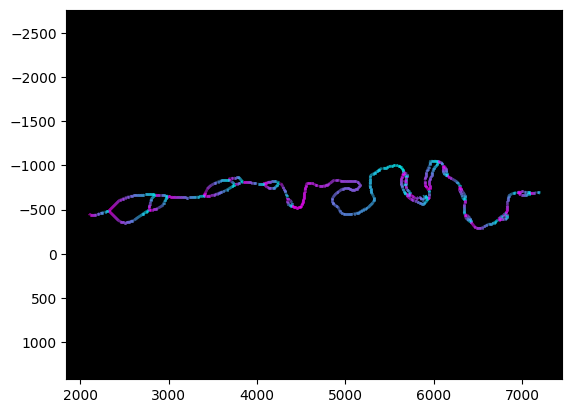

In [23]:
papua.plot('directions')

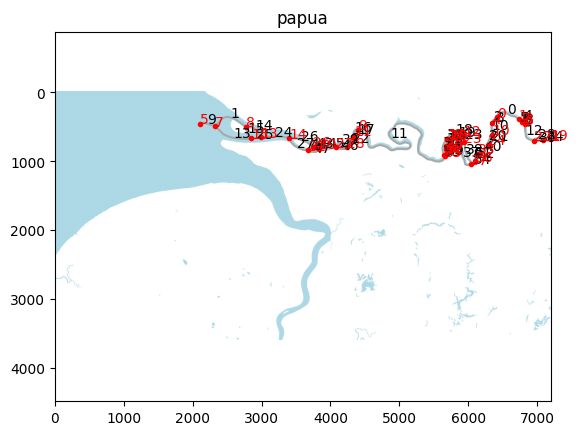

In [24]:
papua.plot('network')

In [25]:
print(papua.unit)

degree


In [26]:
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform # Added calculate_default_transform
import numpy as np
import os

# --- Step 1: Reproject the input mask to a meter-based CRS ---

# Define the current mask path (from previous cells)
original_mask_path = mask_path
# Define the path for the reprojected mask
reprojected_mask_path = '/content/mask_reprojected.tif'

# Open the original mask to get its properties
with rasterio.open(original_mask_path) as src:
    # Get current CRS and transform
    src_crs = src.crs
    src_transform = src.transform
    src_height = src.height
    src_width = src.width
    src_data = src.read(1) # Read the first band

    # Define the target CRS (e.g., UTM Zone 54S for Papua region)
    # You might need to adjust this EPSG code based on the exact location
    # For latitudes -80 to 84, UTM zones are 6 degrees longitude wide.
    # Longitude 138 E, Latitude -7 S. This falls into UTM zone 54S (138E-144E). EPSG:32754.
    # If your area is more to the west, e.g., 132E-138E, use 53S (EPSG:32753).
    dst_crs = 'EPSG:32754' # Example: UTM Zone 54 South

    print(f"Original mask CRS: {src_crs}")
    print(f"Target CRS for reprojection: {dst_crs}")

    # Calculate the transform and dimensions of the reprojected image
    # Use calculate_default_transform with src_crs, dst_crs, width, height, and explicit bounds
    dst_transform, dst_width, dst_height = calculate_default_transform(
        src_crs,
        dst_crs,
        width=src_width,
        height=src_height,
        left=src.bounds.left,
        bottom=src.bounds.bottom,
        right=src.bounds.right,
        top=src.bounds.top
    )

    # Create a destination array with the calculated dimensions
    dst_data = np.zeros((dst_height, dst_width), dtype=src_data.dtype)

    # Perform the reprojection
    reproject(
        source=src_data,
        destination=dst_data,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
        num_threads=os.cpu_count()
    )

    # Write the reprojected mask to a new file
    profile = src.profile.copy()
    profile.update({
        'crs': dst_crs,
        'transform': dst_transform,
        'width': dst_width,
        'height': dst_height,
        'nodata': 0 # Assuming 0 is background and nodata value
    })

    with rasterio.open(reprojected_mask_path, 'w', **profile) as dst:
        dst.write(dst_data, 1)

print(f"Mask successfully reprojected to {reprojected_mask_path} with CRS {dst_crs}")

# --- Step 2: Re-initialize papua object with the reprojected mask ---

import importlib
import sys
import os

# Ensure the cloned RivGraph path is at the very beginning of sys.path
rivgraph_repo_path = '/content/RivGraph'
if rivgraph_repo_path in sys.path:
    sys.path.remove(rivgraph_repo_path)
sys.path.insert(0, rivgraph_repo_path)

# Aggressively remove RivGraph related modules from sys.modules to force a clean reload
for module_name in list(sys.modules.keys()):
    if 'rivgraph' in module_name:
        del sys.modules[module_name]

# Now, import rivgraph.classes cleanly
import rivgraph.classes
from rivgraph.classes import delta

# Verify which rivgraph.classes was loaded
print(f"Loaded rivgraph.classes from: {rivgraph.classes.__file__}")

# Re-instantiate the papua object with the reloaded delta class
# Use the new reprojected mask_path here.
# The variables 'name' and 'results_folder' are expected to be defined from previous cells.
papua = delta(name, reprojected_mask_path, results_folder=results_folder, verbose=True)

print(f"Current unit after reprojection and re-initialization: {papua.unit}")

# --- Step 3: Recompute skeleton, network, widths, and lengths ---
# The reprojected mask now has units in meters, so these calculations will be in meters.
papua.skeletonize()
papua.compute_network()
papua.compute_link_width_and_length()

print("Skeleton, network, and link widths/lengths have been recomputed in meters.")

# You can now re-run the plotting cells (PmfmWR6PHYtb and TWGvBKXjIc6D)
# to see the histograms with x-axes in meters. Remember to update the xlabel strings manually.

Original mask CRS: EPSG:4326
Target CRS for reprojection: EPSG:32754


Mask successfully reprojected to /content/mask_reprojected.tif with CRS EPSG:32754
Loaded rivgraph.classes from: /content/RivGraph/rivgraph/classes.py
---------- New Run ----------
Current unit after reprojection and re-initialization: meter
Resolving links and nodes...
links and nodes have been resolved.
Computing distance transform...
distance transform done.
Computing link widths and lengths...
link widths and lengths computed.
Skeleton, network, and link widths/lengths have been recomputed in meters.


In [27]:
print(papua.unit)

meter


Computing link widths and lengths...
link widths and lengths computed.


Text(0.5, 1.0, 'Histogram of link lengths')

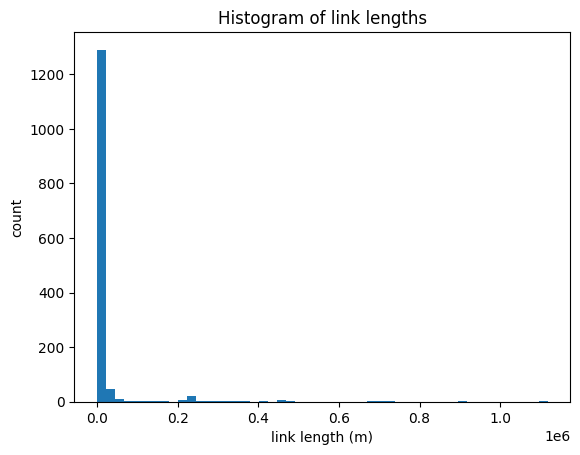

In [28]:
# Compute link widths and lengths
papua.compute_link_width_and_length()

# Lets look at histograms of link widths and lengths:
trash = plt.hist(papua.links['len_adj'], bins=50)
plt.ylabel('count')
plt.xlabel('link length (m)')
plt.title('Histogram of link lengths')

Text(0.5, 1.0, 'Histogram of link widths')

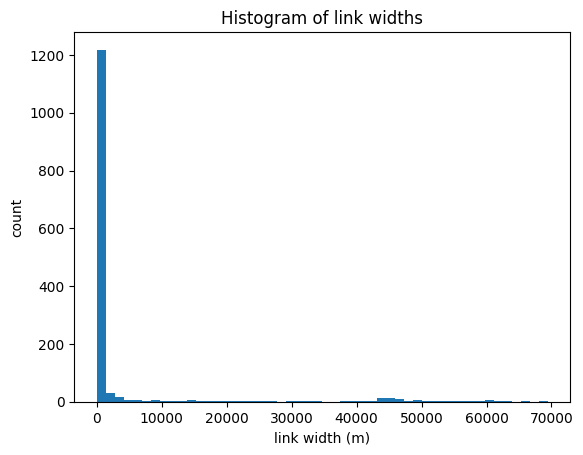

In [29]:
trash = plt.hist(papua.links['wid_adj'], bins=50)
plt.ylabel('count')
plt.xlabel('link width (m)')
plt.title('Histogram of link widths')

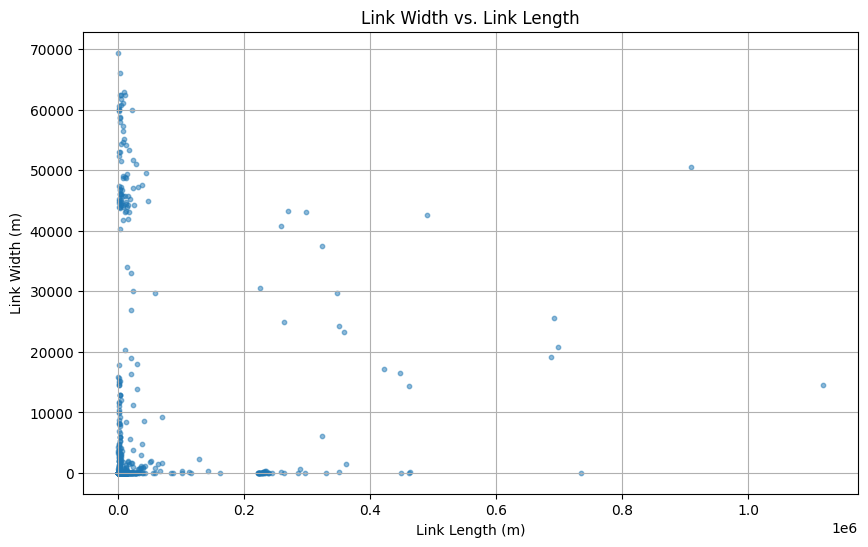

In [32]:
import matplotlib.pyplot as plt

# Extract adjusted link lengths and widths
link_lengths = papua.links['len_adj']
link_widths = papua.links['wid_adj']

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(link_lengths, link_widths, alpha=0.5, s=10) # 's' controls marker size
plt.title('Link Width vs. Link Length')
plt.xlabel('Link Length (m)')
plt.ylabel('Link Width (m)')
plt.grid(True)
plt.show()

In [38]:
import geopandas as gpd
import pandas as pd
import os

# Explicitly construct the path to the exported links GeoPackage
# Using the globally defined 'results_folder' variable, as 'papua.results_folder' is causing an AttributeError.
links_gpkg_path = os.path.join(results_folder, f'{papua.name}_links.gpkg')

# Ensure the file exists
if not os.path.exists(links_gpkg_path):
    print(f"Error: Links GeoPackage not found at {links_gpkg_path}")
    print("Please ensure papua.to_geovectors(ftype='gpkg') was run successfully after re-initialization.")
else:
    print(f"Loading links from: {links_gpkg_path}")
    # Load the links GeoDataFrame
    links_gdf = gpd.read_file(links_gpkg_path)

    # Print columns for debugging
    print("Columns in links_gdf:", links_gdf.columns.tolist())
    print("First few rows of links_gdf:\n", links_gdf.head())

    # Create a temporary DataFrame from papua.links for length and width
    # Ensure 'id' in papua.links corresponds to 'id_link' in links_gdf
    papua_links_df = pd.DataFrame({
        'id_link': papua.links['id'], # This is the ID from the papua.links dict
        'length_m': papua.links['len_adj'],
        'width_m': papua.links['wid_adj']
    })

    # Merge the GeoDataFrame with the papua_links_df to get length and width
    # The 'id_link' from links_gdf will match 'id_link' from papua_links_df
    merged_gdf = links_gdf.merge(papua_links_df, on='id_link', how='left')

    # Prepare data for CSV
    csv_data = []

    for index, row in merged_gdf.iterrows():
        link_id = row['id_link']
        length = row['length_m']
        width = row['width_m']

        # Extract start and end coordinates from the LineString geometry
        if row.geometry and row.geometry.geom_type == 'LineString':
            # RivGraph stores coordinates as (lon, lat)
            start_lon, start_lat = row.geometry.coords[0]
            end_lon, end_lat = row.geometry.coords[-1]
        else:
            start_lon, start_lat = None, None
            end_lon, end_lat = None, None

        csv_data.append({
            'link_id': link_id,
            'length_m': length,
            'width_m': width,
            'start_lon': start_lon,
            'start_lat': start_lat,
            'end_lon': end_lon,
            'end_lat': end_lat
        })

    # Create a pandas DataFrame from the collected data
    df_export = pd.DataFrame(csv_data)

    # Define the output CSV file path in Google Drive
    csv_output_path = os.path.join(results_folder, 'papua_links_attributes_coords.csv')

    # Save the DataFrame to a CSV file
    df_export.to_csv(csv_output_path, index=False)

    print(f"CSV file saved to: {csv_output_path}")
    print("First 5 rows of the generated CSV:")
    print(df_export.head())

Loading links from: /content/drive/My Drive/es2/papua_links.gpkg
Columns in links_gdf: ['id_link', 'idx_link', 'id_nodes', 'n_nodes', 'id_us_node', 'id_ds_node', 'is_inlet', 'is_outlet', 'type_io', 'schema_rg', 'link_conn', 'geometry']
First few rows of links_gdf:
    id_link                                           idx_link id_nodes  \
0       22  4504970, 4512171, 4519372, 4526572, 4533773, 4...   11, 28   
1       46  5750646, 5757847, 5765048, 5772248, 5779449, 5...   28, 27   
2       39  5750646, 5743444, 5736242, 5729040, 5721838, 5...   28, 27   
3       17  4504970, 4497770, 4490570, 4490571, 4483371, 4...    11, 9   
4       45  5714470, 5714469, 5714468, 5714467, 5714466, 5...   27, 29   

   n_nodes id_us_node id_ds_node  is_inlet  is_outlet  type_io schema_rg  \
0        2       None       None     False      False  neither     rg-v1   
1        2       None       None     False      False  neither     rg-v1   
2        2       None       None     False      False  neithe